# Лабораторная работа №4

**Тема:** линейные модели, SVM и деревья решений.

**Цель работы:** изучить применение линейной модели, SVM и дерева решений для задачи регрессии, сравнить качество моделей и проанализировать важность признаков дерева решений.

**Датасеты:** `lr3/pokemon_complete.csv`, `lr3/pokemon_types.csv`.


## Описание задания

В работе решается задача регрессии: необходимо спрогнозировать базовый опыт Pokémon `base_experience` по его боевым характеристикам, физическим параметрам, поколению, редкости, категориальным признакам и сведениям о взаимодействиях типов.

Для выполнения задания используются следующие модели:

- линейная регрессия;
- SVM-регрессия (`SVR`);
- дерево решений для регрессии.

Качество моделей оценивается с помощью двух метрик, подходящих для задачи регрессии: `MAE` и `R2`. Также строится график важности признаков дерева решений и выводятся правила дерева в текстовом виде.


## Импорт библиотек


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

%matplotlib inline
plt.style.use('default')
RANDOM_STATE = 42


## Загрузка данных


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

pokemon_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_complete.csv')
types_df = pd.read_csv(PROJECT_ROOT / 'lr3' / 'pokemon_types.csv')

print('Размер основной таблицы:', pokemon_df.shape)
print('Размер таблицы типов:', types_df.shape)
display(pokemon_df.head())
display(types_df.head())


Размер основной таблицы: (1350, 31)
Размер таблицы типов: (18, 7)


,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,...,shape,egg_groups,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birt...,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appe...",https://raw.githubusercontent.com/PokeAPI/spri...
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,...,quadruped,monster|plant,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar en...,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,Charmander,Fire,NaN,39,52,43,60,50,65,...,upright,monster|dragon,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, s...",https://raw.githubusercontent.com/PokeAPI/spri...
4,5,Charmeleon,Fire,NaN,58,64,58,80,65,80,...,upright,monster|dragon,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates t...",https://raw.githubusercontent.com/PokeAPI/spri...


,type,double_damage_to,half_damage_to,no_damage_to,double_damage_from,half_damage_from,no_damage_from
0,normal,NaN,rock|steel,ghost,fighting,NaN,ghost
1,fighting,normal|rock|steel|ice|dark,flying|poison|bug|psychic|fairy,ghost,flying|psychic|fairy,rock|bug|dark,NaN
2,flying,fighting|bug|grass,rock|steel|electric,NaN,rock|electric|ice,fighting|bug|grass,ground
3,poison,grass|fairy,poison|ground|rock|ghost,steel,ground|psychic,fighting|poison|bug|grass|fairy,NaN
4,ground,poison|rock|steel|fire|electric,bug|grass,flying,water|grass|ice,poison|rock,electric


## Предварительный анализ

Целевой признак `base_experience` содержит пропуски, поэтому строки без целевого значения удаляются. Пропуски в признаках обрабатываются внутри пайплайна: числовые признаки заполняются медианой, категориальные признаки — самым частым значением.


In [3]:
missing_summary = pokemon_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


habitat            830
type_2             585
hidden_ability     362
sprite_url          60
base_experience     48
abilities           25
dtype: int64

In [4]:
pokemon_df['base_experience'].describe()


count    1302.000000
mean      161.943932
std        82.532554
min        36.000000
25%        71.000000
50%       165.000000
75%       222.500000
max       608.000000
Name: base_experience, dtype: float64

## Формирование признаков из таблицы типов


In [5]:
def count_type_list(value):
    """Считает количество типов в строке вида 'fire|water'."""
    if pd.isna(value) or value == '':
        return 0
    return len(str(value).split('|'))

interaction_columns = [
    'double_damage_to',
    'half_damage_to',
    'no_damage_to',
    'double_damage_from',
    'half_damage_from',
    'no_damage_from',
]

type_features = types_df.copy()
type_features['type'] = type_features['type'].str.lower()
for column in interaction_columns:
    type_features[f'{column}_count'] = type_features[column].apply(count_type_list)

type_features = type_features[['type'] + [f'{column}_count' for column in interaction_columns]]
type_features.head()


,type,double_damage_to_count,half_damage_to_count,no_damage_to_count,double_damage_from_count,half_damage_from_count,no_damage_from_count
0,normal,0,2,1,1,0,1
1,fighting,5,5,1,3,3,0
2,flying,3,3,0,3,3,1
3,poison,2,4,1,2,5,0
4,ground,5,2,1,3,2,1


In [6]:
primary_type_features = type_features.add_prefix('type_1_').rename(columns={'type_1_type': 'type_1_key'})
secondary_type_features = type_features.add_prefix('type_2_').rename(columns={'type_2_type': 'type_2_key'})

data = pokemon_df.copy()
data['type_1_key'] = data['type_1'].str.lower()
data['type_2_key'] = data['type_2'].str.lower()

data = data.merge(primary_type_features, on='type_1_key', how='left')
data = data.merge(secondary_type_features, on='type_2_key', how='left')

type_count_columns = [column for column in data.columns if column.endswith('_count')]
data[type_count_columns] = data[type_count_columns].fillna(0)

data[type_count_columns].head()


,type_1_double_damage_to_count,type_1_half_damage_to_count,type_1_no_damage_to_count,type_1_double_damage_from_count,type_1_half_damage_from_count,type_1_no_damage_from_count,type_2_double_damage_to_count,type_2_half_damage_to_count,type_2_no_damage_to_count,type_2_double_damage_from_count,type_2_half_damage_from_count,type_2_no_damage_from_count
0,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
1,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
2,3,7,0,5,4,0,2.0,4.0,1.0,2.0,5.0,0.0
3,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,4,0,3,6,0,0.0,0.0,0.0,0.0,0.0,0.0


## Подготовка обучающей и тестовой выборки

Из признаков исключаются текстовые поля, URL и идентификаторы, которые не нужны для обучения модели. Категориальные признаки кодируются методом one-hot encoding, числовые признаки масштабируются для линейной регрессии и SVM.


In [7]:
target = 'base_experience'

feature_columns = [
    'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
    'base_stat_total', 'height_m', 'weight_kg', 'capture_rate', 'base_happiness',
    'generation', 'is_legendary', 'is_mythical', 'is_baby',
    'type_1', 'type_2', 'color', 'shape', 'habitat', 'growth_rate',
] + type_count_columns

model_df = data[feature_columns + [target]].dropna(subset=[target]).copy()

bool_columns = model_df.select_dtypes(include=['bool']).columns.tolist()
model_df[bool_columns] = model_df[bool_columns].astype(int)

X = model_df[feature_columns]
y = model_df[target]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))


Размер X: (1302, 33)
Размер y: (1302,)
Числовых признаков: 26
Категориальных признаков: 7


C:\Users\Den\AppData\Local\Temp\ipykernel_28676\3222041618.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)


Обучающая выборка: (976, 33)
Тестовая выборка: (326, 33)


In [9]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])


## Обучение моделей


In [10]:
models = {
    'Линейная регрессия': LinearRegression(),
    'SVM': SVR(kernel='rbf', C=10, epsilon=0.1),
    'Дерево решений': DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
metrics = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    trained_models[model_name] = pipeline
    metrics.append({
        'model': model_name,
        'MAE': mean_absolute_error(y_test, predictions),
        'R2': r2_score(y_test, predictions),
    })

metrics_df = pd.DataFrame(metrics).sort_values(by='MAE')
metrics_df


,model,MAE,R2
2,Дерево решений,15.416835,0.897875
0,Линейная регрессия,18.659763,0.913780
1,SVM,20.493286,0.820607


## Сравнение качества моделей


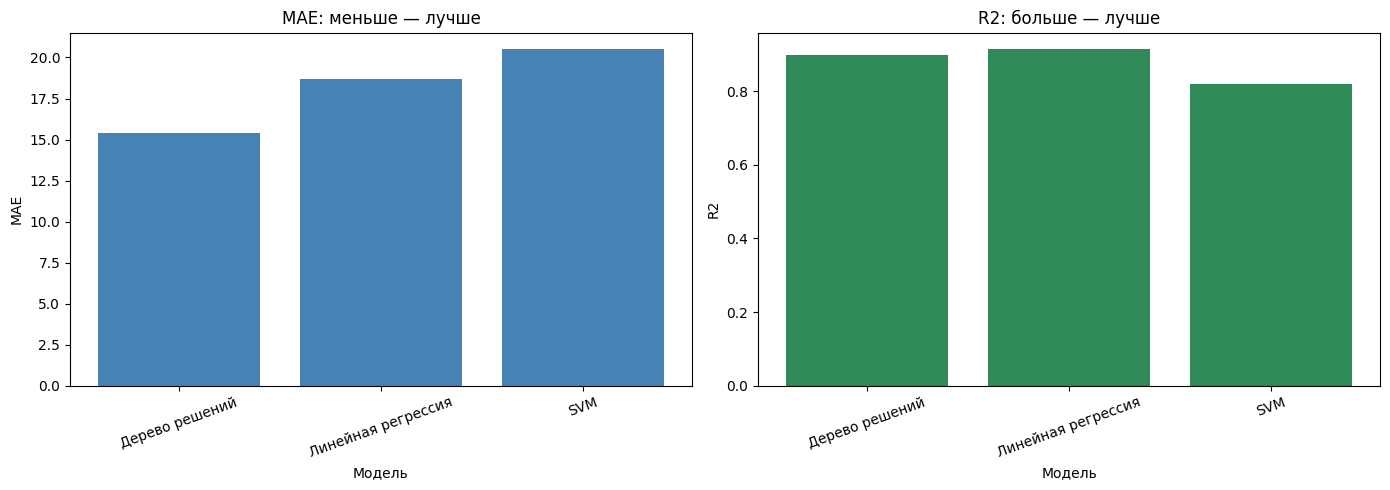

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(metrics_df['model'], metrics_df['MAE'], color='steelblue')
axes[0].set_title('MAE: меньше — лучше')
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(metrics_df['model'], metrics_df['R2'], color='seagreen')
axes[1].set_title('R2: больше — лучше')
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [12]:
best_model_name = metrics_df.iloc[0]['model']
print('Лучшая модель по MAE:', best_model_name)
metrics_df


Лучшая модель по MAE: Дерево решений


,model,MAE,R2
2,Дерево решений,15.416835,0.897875
0,Линейная регрессия,18.659763,0.913780
1,SVM,20.493286,0.820607


## Важность признаков в дереве решений


In [13]:
tree_pipeline = trained_models['Дерево решений']
preprocessor_fitted = tree_pipeline.named_steps['preprocessor']
tree_model = tree_pipeline.named_steps['model']

encoded_feature_names = preprocessor_fitted.get_feature_names_out()
feature_importance = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': tree_model.feature_importances_,
}).sort_values('importance', ascending=False)

feature_importance.head(15)


,feature,importance
6,num__base_stat_total,0.962012
9,num__capture_rate,0.013878
0,num__hp,0.009552
5,num__speed,0.003983
107,cat__growth_rate_medium-slow,0.003647
93,cat__shape_upright,0.002006
8,num__weight_kg,0.001620
4,num__sp_defense,0.001201
76,cat__color_pink,0.000689
35,cat__type_1_Bug,0.000556


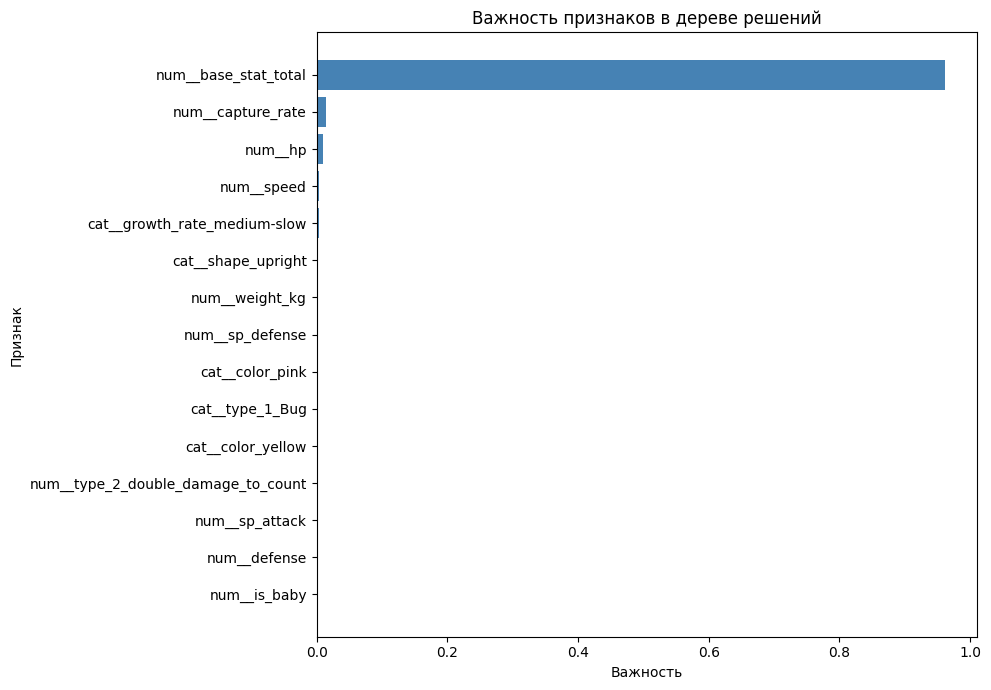

In [14]:
top_features = feature_importance.head(15).sort_values('importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.title('Важность признаков в дереве решений')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


## Визуализация дерева решений


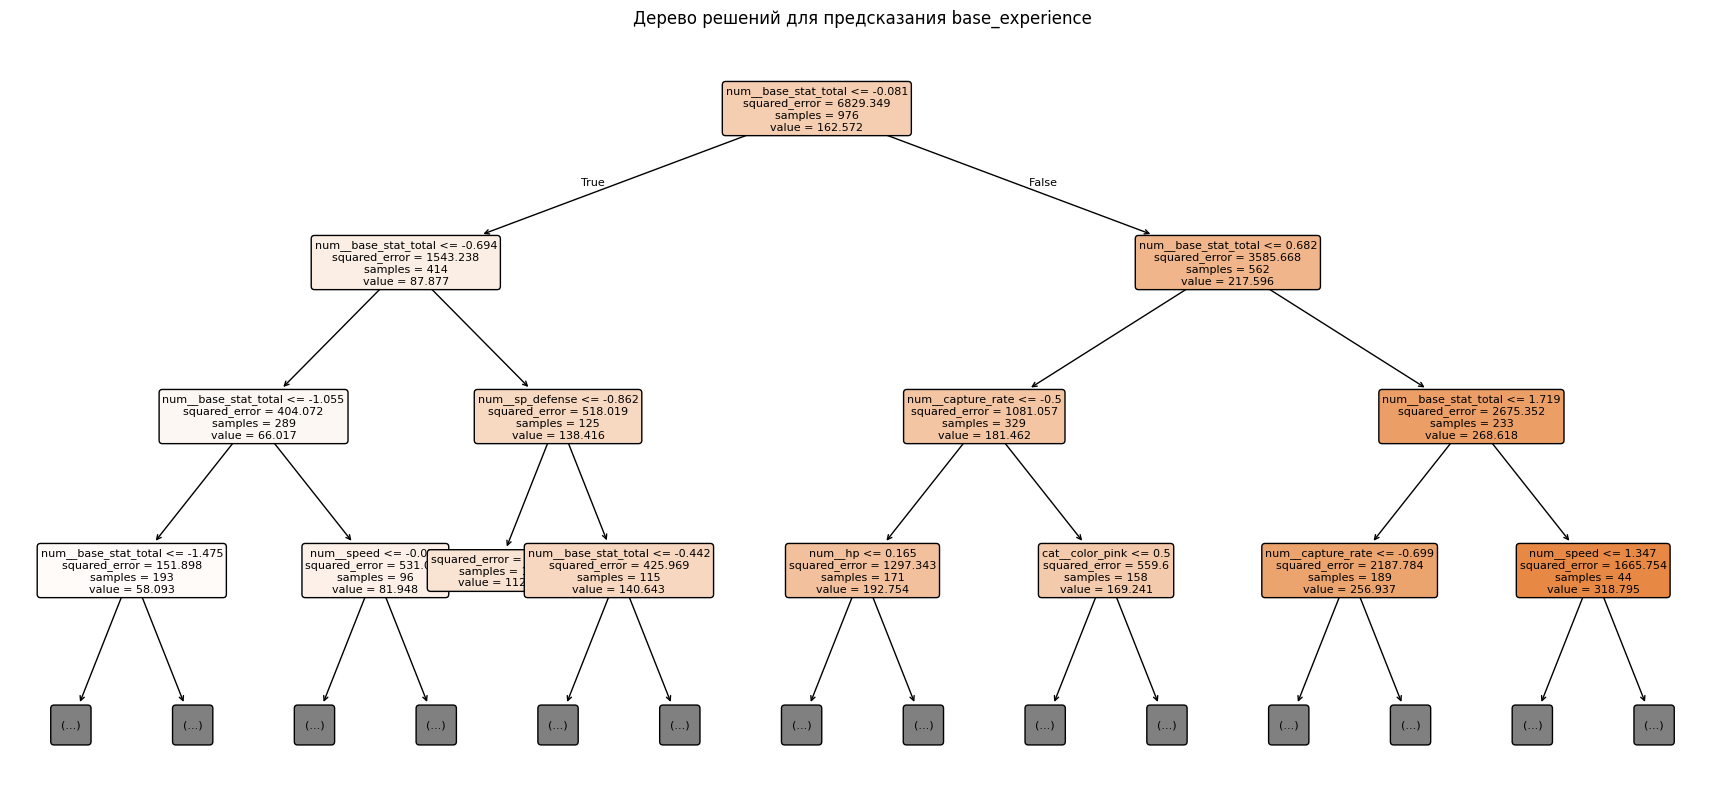

In [15]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=encoded_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title('Дерево решений для предсказания base_experience')
plt.show()


## Правила дерева решений в текстовом виде


In [16]:
tree_rules = export_text(
    tree_model,
    feature_names=list(encoded_feature_names),
    max_depth=4,
)
print(tree_rules)


|--- num__base_stat_total <= -0.08
|   |--- num__base_stat_total <= -0.69
|   |   |--- num__base_stat_total <= -1.05
|   |   |   |--- num__base_stat_total <= -1.47
|   |   |   |   |--- num__capture_rate <= 0.43
|   |   |   |   |   |--- value: [62.73]
|   |   |   |   |--- num__capture_rate >  0.43
|   |   |   |   |   |--- value: [48.43]
|   |   |   |--- num__base_stat_total >  -1.47
|   |   |   |   |--- num__capture_rate <= 1.12
|   |   |   |   |   |--- value: [66.04]
|   |   |   |   |--- num__capture_rate >  1.12
|   |   |   |   |   |--- value: [60.01]
|   |   |--- num__base_stat_total >  -1.05
|   |   |   |--- num__speed <= -0.03
|   |   |   |   |--- cat__growth_rate_medium-slow <= 0.50
|   |   |   |   |   |--- value: [70.56]
|   |   |   |   |--- cat__growth_rate_medium-slow >  0.50
|   |   |   |   |   |--- value: [94.10]
|   |   |   |--- num__speed >  -0.03
|   |   |   |   |--- cat__color_yellow <= 0.50
|   |   |   |   |   |--- value: [89.50]
|   |   |   |   |--- cat__color_yellow > 

## Вывод

В ходе лабораторной работы были загружены и подготовлены данные о Pokémon, выполнено заполнение пропусков и кодирование категориальных признаков. Выборка была разделена на обучающую и тестовую с помощью `train_test_split`.

Были обучены три модели: линейная регрессия, SVM и дерево решений. Качество моделей сравнивается по метрикам `MAE` и `R2`. Дополнительно для дерева решений построен график важности признаков и выведены правила дерева, что позволяет интерпретировать вклад характеристик Pokémon в предсказание базового опыта.
